# Does a black box beat the classical prepayment equation?

Companion notebook to Chapter 9, *Why Pure Black Boxes Fail on the Trading Desk*, and to the script `ml_vs_classical_rmse.py` beside it. The functions come from that script, so the notebook and the numbers quoted in the chapter cannot drift apart. What the notebook adds is the pictures.

- **Loans**: about 12,700 loans Fannie Mae bought in 2000Q1 (the first 120 MB of the Single-Family Loan Performance file), followed month by month through the 2001-2003 refinancing boom.
- **Rates**: Freddie Mac's weekly 30-year survey rate, averaged by month. A loan's refinance incentive is its note rate minus last month's market rate.

The first run needs network access and caches the download under `~/.cache/mortgagekit`. Use the `Python (usao)` kernel.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Works whether the notebook runs from its own folder or from the repo root.
here = Path.cwd()
if not (here / "ml_vs_classical_rmse.py").exists():
    here = here / "chapter9-ai-ml-modeling" / "code"
sys.path.insert(0, str(here))

import ml_vs_classical_rmse as exp
from mortgagekit.figstyle import BORROWER, DEALER, LENDER, SERVICER, SLATE, configure_book_style

configure_book_style()
%matplotlib inline
COLORS = {"S-curve, incentive only": SERVICER, "Multi-factor equation": LENDER, "Gradient-boosted tree": DEALER}

## The panel

One row per loan per month. The target is 1 in the month a loan pays off voluntarily (zero-balance code 01) and 0 otherwise. Credit terminations are a competing risk, so those rows are dropped rather than counted as prepayments.

12,732 loans, 473,145 loan-months, 12,463 voluntary payoffs


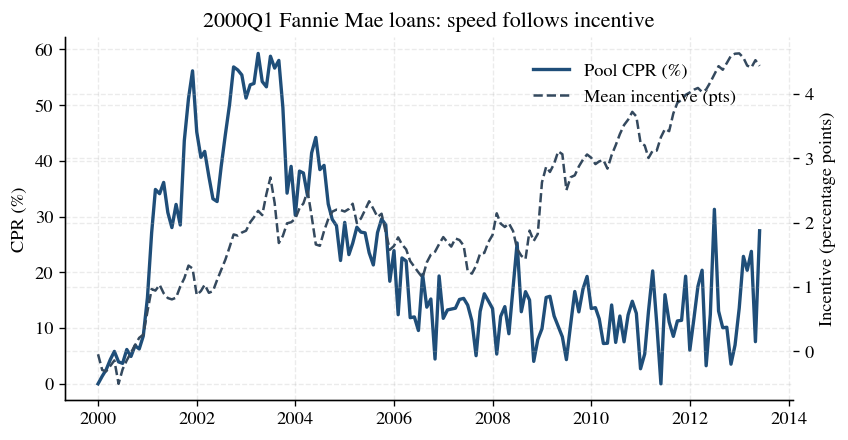

In [2]:
x, y, loans, periods = exp.build_panel()
print(f"{len(np.unique(loans)):,} loans, {len(y):,} loan-months, {int(y.sum()):,} voluntary payoffs")

# Pool CPR of the whole sample by month, with the refinance incentive it faced.
months = np.unique(periods)
alive = np.array([(periods == m).sum() for m in months])
pool_cpr = np.array([exp.cpr(y[periods == m].mean()) for m in months]) * 100
pool_inc = np.array([x[periods == m, exp.INCENTIVE].mean() for m in months])
keep = alive >= exp.MIN_LOANS_PER_MONTH
dates = np.array([np.datetime64(f"{m // 100}-{m % 100:02d}") for m in months])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(dates[keep], pool_cpr[keep], color=BORROWER, lw=2, label="Pool CPR (%)")
ax.set_ylabel("CPR (%)")
ax2 = ax.twinx()
ax2.plot(dates[keep], pool_inc[keep], color=SLATE, lw=1.5, ls="--", label="Mean incentive (pts)")
ax2.set_ylabel("Incentive (percentage points)")
ax.set_title("2000Q1 Fannie Mae loans: speed follows incentive")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88), frameon=False)
fig.tight_layout()

## Three models, held-out loans

The usual historical test holds out whole loans (30%), so no loan sits on both sides of the split.

1. **S-curve, incentive only**: the single classical equation.
2. **Multi-factor equation**: the S-curve times a seasoning ramp, a burnout decay and a seasonal, every factor hand-specified.
3. **Gradient-boosted tree**: the same inputs plus credit score, LTV, DTI, loan size, purpose, channel and occupancy, with no shape imposed.

In [3]:
rng = np.random.default_rng(exp.SEED)
unique_loans = np.unique(loans)
held_out = np.isin(loans, rng.choice(unique_loans, int(exp.TEST_SHARE * len(unique_loans)), replace=False))

models = exp.fit_all(x[~held_out], y[~held_out])
exp.report("Held-out loans, same calendar period", models, x[held_out], y[held_out], periods[held_out])


Held-out loans, same calendar period
  model                       loan-month RMSE  monthly CPR RMSE
  S-curve, incentive only             0.15861         11.42 CPR
  Multi-factor equation               0.15800          8.19 CPR
  Gradient-boosted tree               0.15718          5.29 CPR
  (70 months with at least 300 held-out loans alive)


Scored one loan-month at a time, the three models are almost tied: each loan-month is a coin flip, and its noise swamps any model. Scored as the held-out group's monthly CPR, which is what a desk trades, the gap is wide. The chart shows where it comes from.

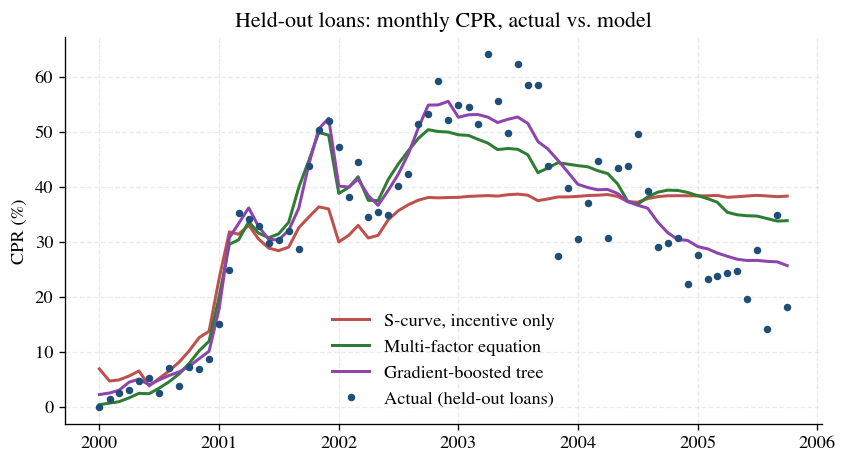

In [4]:
def monthly_cpr(predicted, y_, p_):
    ms = [m for m in np.unique(p_) if (p_ == m).sum() >= exp.MIN_LOANS_PER_MONTH]
    d = np.array([np.datetime64(f"{m // 100}-{m % 100:02d}") for m in ms])
    actual = np.array([exp.cpr(y_[p_ == m].mean()) for m in ms]) * 100
    model = np.array([exp.cpr(predicted[p_ == m].mean()) for m in ms]) * 100
    return d, actual, model

fig, ax = plt.subplots(figsize=(7.2, 4.0))
for name, predict in models.items():
    d, actual, model = monthly_cpr(predict(x[held_out]), y[held_out], periods[held_out])
    ax.plot(d, model, color=COLORS[name], lw=1.8, label=name)
ax.plot(d, actual, color=BORROWER, lw=0, marker="o", ms=3.5, label="Actual (held-out loans)")
ax.set_ylabel("CPR (%)")
ax.set_title("Held-out loans: monthly CPR, actual vs. model")
ax.legend(frameon=False)
fig.tight_layout()

## What the score does not see: the shape

RMSE rewards matching history. It never asks whether a forecast moves the right way when rates move. Raise every held-out loan's incentive by 25bp: a sensible model must not predict *slower* prepayment.

In [5]:
tree = models["Gradient-boosted tree"]
bumped = x[held_out].copy()
bumped[:, exp.INCENTIVE] += 0.25
wrong_way = np.mean(tree(bumped) < tree(x[held_out]) - 1e-12)
print(f"+25bp of incentive lowers the tree's forecast on {wrong_way:.0%} of held-out loan-months")

+25bp of incentive lowers the tree's forecast on 12% of held-out loan-months


Sweep the incentive across a grid for the held-out loans and plot the model's CPR. On the left it is averaged over 5,000 loans; on the right it is a single loan, which is what a desk revalues when it bumps rates. The equations are smooth and rising by construction. The tree is a staircase, and some of its steps go down.

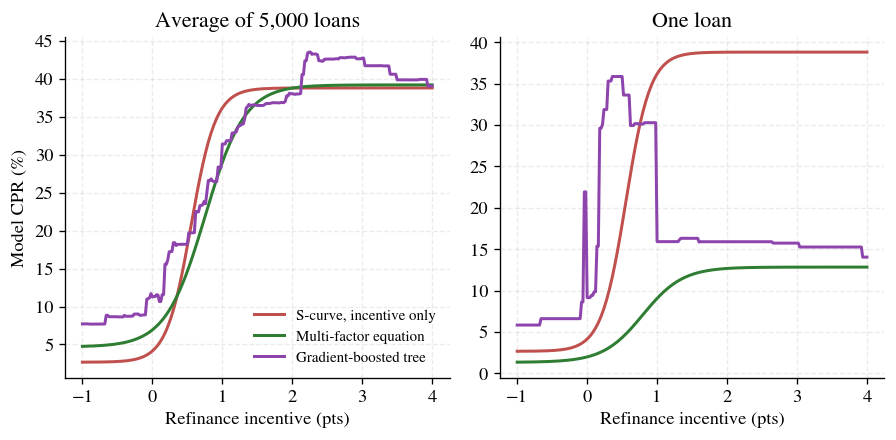

In [6]:
grid = np.arange(-1.0, 4.01, 0.02)
sample = x[held_out][np.random.default_rng(1).choice(held_out.sum(), 5000, replace=False)]
one_loan = sample[:1]

def response(predict, rows):
    out = []
    for g in grid:
        z = rows.copy()
        z[:, exp.INCENTIVE] = g
        out.append(exp.cpr(predict(z).mean()) * 100)
    return np.array(out)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), sharey=False)
for ax, rows, title in [(axes[0], sample, "Average of 5,000 loans"), (axes[1], one_loan, "One loan")]:
    for name, predict in models.items():
        ax.plot(grid, response(predict, rows), color=COLORS[name], lw=1.8, label=name)
    ax.set_xlabel("Refinance incentive (pts)")
    ax.set_title(title)
axes[0].set_ylabel("Model CPR (%)")
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()

## A harder test: out of time

Fit on 2000-2001 only, then forecast the 2002-2003 boom, when incentives ran wider than anything in the training years.


Out of time: fit on 2000-2001, forecast 2002-2003
  model                       loan-month RMSE  monthly CPR RMSE
  S-curve, incentive only             0.22150          7.65 CPR
  Multi-factor equation               0.22149          7.66 CPR
  Gradient-boosted tree               0.22126          9.03 CPR
  (24 months with at least 300 held-out loans alive)


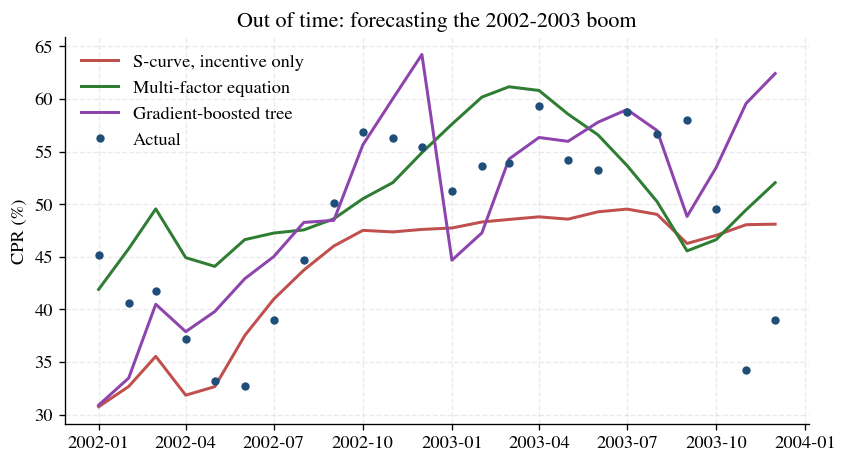

In [7]:
train = periods < 200201
test = (periods >= 200201) & (periods < 200401)
models_oot = exp.fit_all(x[train], y[train])
exp.report("Out of time: fit on 2000-2001, forecast 2002-2003", models_oot, x[test], y[test], periods[test])

fig, ax = plt.subplots(figsize=(7.2, 4.0))
for name, predict in models_oot.items():
    d, actual, model = monthly_cpr(predict(x[test]), y[test], periods[test])
    ax.plot(d, model, color=COLORS[name], lw=1.8, label=name)
ax.plot(d, actual, color=BORROWER, lw=0, marker="o", ms=4, label="Actual")
ax.set_ylabel("CPR (%)")
ax.set_title("Out of time: forecasting the 2002-2003 boom")
ax.legend(frameon=False)
fig.tight_layout()

## Takeaways

- On held-out loans from the same period, the tree beats both classical equations, and by a wide margin at the pool level. The chapter's claim holds.
- The same tree forecasts *slower* prepayment for more incentive on a meaningful share of loan-months. RMSE cannot see this; a hedge ratio can.
- Asked to forecast a new regime, the tree loses its lead. A lower historical RMSE is not evidence that a model will survive the next refinancing wave.

This is the case for the hybrid design in the rest of Chapter 9: keep the economic equation as the backbone, and let the machine learn a bounded, monotone residual on top.